<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_9_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1

Fit a decision tree classifier on the [wine data sets](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) with no limits on maximum depth, features, or leaves. Determine how many nodes are present and what the depth of this (very large) tree is. Using this tree, measure the prediction error in the train and test sets. (1p)

Number of nodes: 13
Tree depth: 4
Train error: 0.0
Test error: 0.05555555555555558


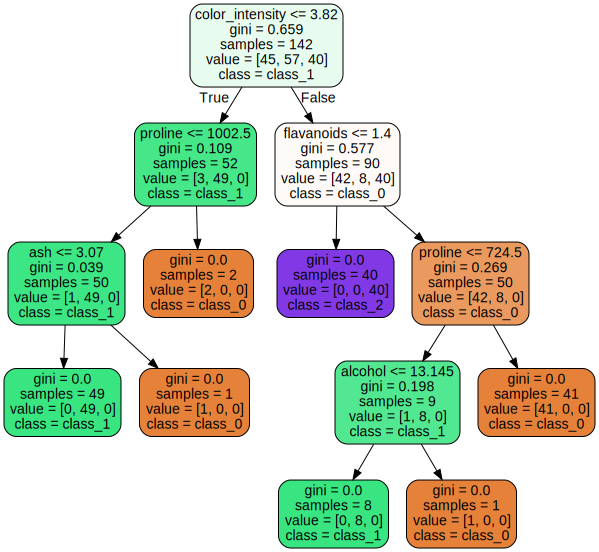

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)

num_nodes = tree_unlimited.tree_.node_count
tree_depth = tree_unlimited.get_depth()

train_accuracy = tree_unlimited.score(X_train, y_train)
test_accuracy = tree_unlimited.score(X_test, y_test)
train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print("Number of nodes:", num_nodes)
print("Tree depth:", tree_depth)
print("Train error:", train_error)
print("Test error:", test_error)

export_graphviz(
  tree_unlimited,
  out_file="wine_tree_unlimited.dot",
  feature_names=wine.feature_names,
  class_names=wine.target_names,
  rounded=True,
  filled=True
)
Source.from_file("wine_tree_unlimited.dot")

### Execise 2
Train two additional decision tree classifiers on the same dataset. In the first tree use the `max_depth` hyperparameter to regularize the depth of the tree. In the second tree, use the `min_samples_leaf=5` for the same purpose. Visualize the grapth of all three models and compare theme. Plot the actual vs predicted classes of the best model. (2p)

Unlimited tree - Train accuracy: 1.0
Unlimited tree - Test accuracy: 0.9444444444444444
Max depth=3 tree - Train accuracy: 0.9929577464788732
Max depth=3 tree - Test accuracy: 0.9444444444444444
Min samples leaf=5 tree - Train accuracy: 0.971830985915493
Min samples leaf=5 tree - Test accuracy: 0.9444444444444444


'Unlimited Tree:'

'Max Depth=3 Tree:'

'Min Samples Leaf=5 Tree:'

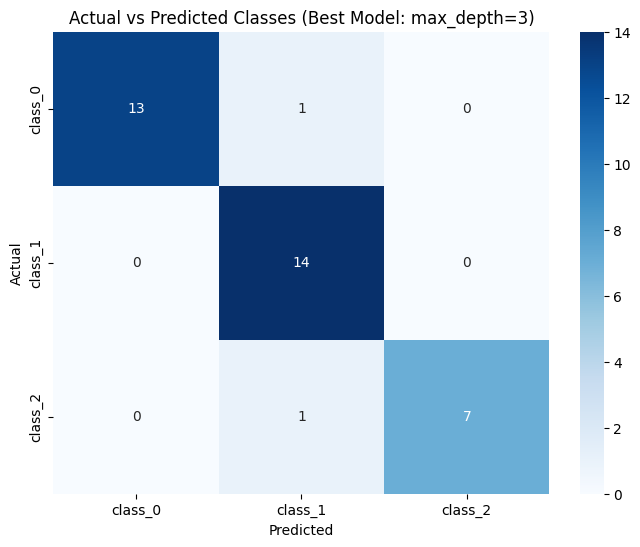

In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix
from graphviz import Source
import matplotlib.pyplot as plt
import seaborn as sns

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)

tree_max_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_min_samples = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

tree_max_depth.fit(X_train, y_train)
tree_min_samples.fit(X_train, y_train)

print("Unlimited tree - Train accuracy:", tree_unlimited.score(X_train, y_train))
print("Unlimited tree - Test accuracy:", tree_unlimited.score(X_test, y_test))
print("Max depth=3 tree - Train accuracy:", tree_max_depth.score(X_train, y_train))
print("Max depth=3 tree - Test accuracy:", tree_max_depth.score(X_test, y_test))
print("Min samples leaf=5 tree - Train accuracy:", tree_min_samples.score(X_train, y_train))
print("Min samples leaf=5 tree - Test accuracy:", tree_min_samples.score(X_test, y_test))

export_graphviz(
  tree_unlimited,
  out_file="tree_unlimited.dot",
  feature_names=wine.feature_names,
  class_names=wine.target_names,
  rounded=True,
  filled=True
)
display("Unlimited Tree:")
Source.from_file("tree_unlimited.dot")

export_graphviz(
  tree_max_depth,
  out_file="tree_max_depth.dot",
  feature_names=wine.feature_names,
  class_names=wine.target_names,
  rounded=True,
  filled=True
)
display("Max Depth=3 Tree:")
Source.from_file("tree_max_depth.dot")

export_graphviz(
  tree_min_samples,
  out_file="tree_min_samples.dot",
  feature_names=wine.feature_names,
  class_names=wine.target_names,
  rounded=True,
  filled=True
)
display("Min Samples Leaf=5 Tree:")
Source.from_file("tree_min_samples.dot")



best_model = tree_max_depth
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted Classes (Best Model: max_depth=3)')


plt.show()